# Evolução dos Casos de Dengue no Brasil (2015–2024)

**Disciplina:** Linguagem de Programação — Análise e Visualização de Dados com Python
**Professor:** Alexandre Neves Louzada
**Aluno:** Raphael Cortes
**Projeto:** G1 — Tema 1


## 1. Introdução

A dengue é uma das principais doenças transmitidas por mosquitos no Brasil e representa um
importante problema de saúde pública. A proliferação do mosquito *Aedes aegypti* está
relacionada a fatores climáticos, ambientais e urbanos, especialmente períodos de chuva
intensa e temperaturas elevadas.

O monitoramento da evolução dos casos de dengue é fundamental para auxiliar ações
preventivas, campanhas de conscientização e políticas públicas de combate à doença. Este
notebook explora um dataset simulado com registros mensais de dengue em 37 municípios
brasileiros entre 2015 e 2024, buscando identificar padrões temporais e regionais e apoiar
a construção do dashboard interativo do projeto.

### Perguntas orientadoras

1. Quais estados apresentam mais casos de dengue?
2. Existem períodos do ano mais críticos?
3. Há crescimento dos casos ao longo dos anos?
4. Existe relação entre chuva e aumento de casos?
5. Quais municípios apresentam maior incidência?
6. Há regiões mais vulneráveis?
7. Quais períodos exigem maior atenção da saúde pública?


## 2. Explicação da base de dados

Arquivo: `dados/simulacao_dengue_brasil.csv` (também replicado em `database/dengue.db`,
tabela `registros_dengue`, via SQLAlchemy — ver `database/models.py`).

| Coluna | Descrição |
|---|---|
| ano | Ano da ocorrência |
| mes | Mês da ocorrência |
| data | Data de referência (1º dia do mês) |
| regiao | Região do Brasil |
| uf | Estado (sigla) |
| municipio | Município |
| populacao | População estimada |
| chuva_mm | Volume médio de chuva (mm) |
| temperatura_media | Temperatura média (°C) |
| casos_dengue | Quantidade de casos registrados |
| internacoes | Internações registradas |
| obitos | Óbitos registrados |
| incidencia_100k | Casos por 100 mil habitantes |
| nivel_alerta | Nível de alerta epidemiológico (Baixo/Médio/Alto) |

Granularidade: 1 linha = 1 município × 1 mês. Cobertura: 10 anos (2015–2024), 12 meses,
37 municípios em 20 estados e 5 regiões — 4.440 registros.


## 3. Leitura dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

sys.path.append(os.path.abspath(".."))
from database.models import carregar_dataframe

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 5)

# Lemos direto do banco SQLite (camada de persistência), que é alimentado pelo CSV
df = carregar_dataframe()
df.head()


,id,ano,mes,data,regiao,uf,municipio,populacao,chuva_mm,temperatura_media,casos_dengue,internacoes,obitos,incidencia_100k,nivel_alerta
0,1,2015,1,2015-01-01,Norte,AM,Manaus,2708209,141.6,26.6,998,43,2,36.85,Médio
1,2,2015,1,2015-01-01,Norte,PA,Belém,711775,161.5,26.4,229,12,0,32.17,Médio
2,3,2015,1,2015-01-01,Norte,PA,Santarém,2249561,128.9,26.1,776,35,2,34.50,Médio
3,4,2015,1,2015-01-01,Norte,RO,Porto Velho,2198291,180.8,28.5,915,51,3,41.62,Médio
4,5,2015,1,2015-01-01,Norte,TO,Palmas,2193271,151.1,24.7,760,37,0,34.65,Médio


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 4440 non-null   int64         
 1   ano                4440 non-null   int64         
 2   mes                4440 non-null   int64         
 3   data               4440 non-null   datetime64[us]
 4   regiao             4440 non-null   str           
 5   uf                 4440 non-null   str           
 6   municipio          4440 non-null   str           
 7   populacao          4440 non-null   int64         
 8   chuva_mm           4440 non-null   float64       
 9   temperatura_media  4440 non-null   float64       
 10  casos_dengue       4440 non-null   int64         
 11  internacoes        4440 non-null   int64         
 12  obitos             4440 non-null   int64         
 13  incidencia_100k    4440 non-null   float64       
 14  nivel_alerta       

In [3]:
df.select_dtypes(include="number").describe().T


,count,mean,std,min,25%,50%,75%,max
id,4440.0,2.220500e+03,1.281862e+03,1.00,1110.750,2220.50,3330.25,4440.00
ano,4440.0,2.019500e+03,2.872605e+00,2015.00,2017.000,2019.50,2022.00,2024.00
mes,4440.0,6.500000e+00,3.452441e+00,1.00,3.750,6.50,9.25,12.00
populacao,4440.0,2.589414e+06,1.392967e+06,150048.00,1404289.750,2608171.50,3781211.25,4994111.00
chuva_mm,4440.0,9.889225e+01,4.921318e+01,0.00,62.775,94.60,135.30,247.60
temperatura_media,4440.0,2.602459e+01,2.957153e+00,15.30,24.600,26.50,28.00,33.80
casos_dengue,4440.0,8.019284e+02,4.659183e+02,26.00,413.000,774.50,1148.25,2239.00
internacoes,4440.0,4.024099e+01,2.419825e+01,0.00,20.000,38.00,58.00,119.00
obitos,4440.0,1.196847e+00,1.321828e+00,0.00,0.000,1.00,2.00,8.00
incidencia_100k,4440.0,3.094032e+01,5.943772e+00,11.69,26.830,30.86,35.06,51.97


## 4. Limpeza e preparação

Verificamos valores nulos, duplicados e ajustamos os tipos das colunas categóricas e de
data para facilitar as próximas etapas de análise.

In [4]:
print("Valores nulos por coluna:")
print(df.isnull().sum())

print("\nLinhas duplicadas:", df.duplicated().shape[0] - df.drop_duplicates().shape[0])

# Ajuste de tipos
df["data"] = pd.to_datetime(df["data"])
for col in ["regiao", "uf", "municipio", "nivel_alerta"]:
    df[col] = df[col].astype("category")

df = df.sort_values(["data", "uf", "municipio"]).reset_index(drop=True)
df.dtypes


Valores nulos por coluna:
id                   0
ano                  0
mes                  0
data                 0
regiao               0
uf                   0
municipio            0
populacao            0
chuva_mm             0
temperatura_media    0
casos_dengue         0
internacoes          0
obitos               0
incidencia_100k      0
nivel_alerta         0
dtype: int64

Linhas duplicadas: 0


id                            int64
ano                           int64
mes                           int64
data                 datetime64[us]
regiao                     category
uf                         category
municipio                  category
populacao                     int64
chuva_mm                    float64
temperatura_media           float64
casos_dengue                  int64
internacoes                   int64
obitos                        int64
incidencia_100k             float64
nivel_alerta               category
dtype: object

## 5. Engenharia de atributos

Criamos colunas derivadas que serão usadas nos KPIs, nos gráficos e no dashboard:
estação do ano, trimestre, taxa de internação e taxa de letalidade.

In [5]:
estacao_por_mes = {
    12: "Verão", 1: "Verão", 2: "Verão",
    3: "Outono", 4: "Outono", 5: "Outono",
    6: "Inverno", 7: "Inverno", 8: "Inverno",
    9: "Primavera", 10: "Primavera", 11: "Primavera",
}

df["estacao"] = df["mes"].map(estacao_por_mes)
df["trimestre"] = df["data"].dt.quarter
df["taxa_internacao_pct"] = (df["internacoes"] / df["casos_dengue"]).replace([np.inf, np.nan], 0) * 100
df["taxa_letalidade_pct"] = (df["obitos"] / df["casos_dengue"]).replace([np.inf, np.nan], 0) * 100
df["mes_nome"] = df["data"].dt.strftime("%b")

df[["data", "municipio", "uf", "casos_dengue", "estacao", "taxa_internacao_pct", "taxa_letalidade_pct"]].head()


,data,municipio,uf,casos_dengue,estacao,taxa_internacao_pct,taxa_letalidade_pct
0,2015-01-01,Manaus,AM,998,Verão,4.308617,0.200401
1,2015-01-01,Feira de Santana,BA,1599,Verão,4.502814,0.500313
2,2015-01-01,Salvador,BA,1709,Verão,4.798128,0.058514
3,2015-01-01,Fortaleza,CE,581,Verão,6.024096,0.000000
4,2015-01-01,Juazeiro do Norte,CE,1914,Verão,5.381400,0.156740


## 6. KPIs

Indicadores agregados exigidos pelo enunciado: total de casos, total de óbitos, média
mensal de casos, estado mais afetado, município crítico e incidência média.

In [6]:
total_casos = int(df["casos_dengue"].sum())
total_obitos = int(df["obitos"].sum())
media_mensal_casos = df.groupby("data")["casos_dengue"].sum().mean()

casos_por_uf = df.groupby("uf", observed=True)["casos_dengue"].sum().sort_values(ascending=False)
estado_mais_afetado = casos_por_uf.index[0]

incidencia_por_municipio = df.groupby("municipio", observed=True)["incidencia_100k"].mean().sort_values(ascending=False)
municipio_critico = incidencia_por_municipio.index[0]

incidencia_media = df["incidencia_100k"].mean()

kpis = {
    "Total de casos (2015-2024)": f"{total_casos:,}".replace(",", "."),
    "Total de óbitos (2015-2024)": f"{total_obitos:,}".replace(",", "."),
    "Média mensal de casos (Brasil)": f"{media_mensal_casos:,.0f}".replace(",", "."),
    "Estado mais afetado (total de casos)": f"{estado_mais_afetado} ({casos_por_uf.iloc[0]:,.0f} casos)".replace(",", "."),
    "Município com maior incidência média": f"{municipio_critico} ({incidencia_por_municipio.iloc[0]:.1f} / 100 mil hab.)",
    "Incidência média nacional": f"{incidencia_media:.1f} / 100 mil hab.",
}

for k, v in kpis.items():
    print(f"- {k}: {v}")


- Total de casos (2015-2024): 3.560.562
- Total de óbitos (2015-2024): 5.314
- Média mensal de casos (Brasil): 29.671
- Estado mais afetado (total de casos): RJ (391.014 casos)
- Município com maior incidência média: Campinas (32.8 / 100 mil hab.)
- Incidência média nacional: 30.9 / 100 mil hab.


## 7. Gráficos

### 7.1 Evolução temporal dos casos (nacional, por ano)

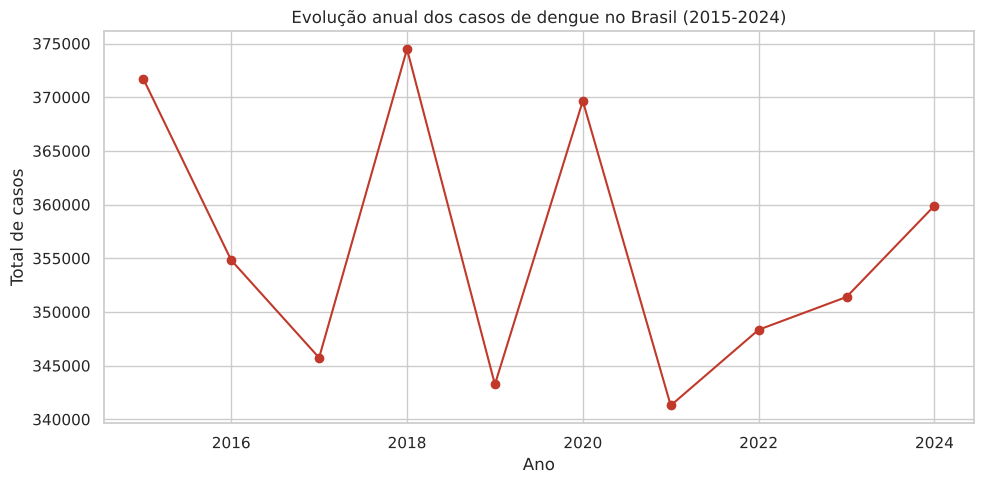

In [7]:
casos_por_ano = df.groupby("ano")["casos_dengue"].sum()

fig, ax = plt.subplots()
casos_por_ano.plot(marker="o", ax=ax, color="#c0392b")
ax.set_title("Evolução anual dos casos de dengue no Brasil (2015-2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("Total de casos")
plt.tight_layout()
plt.savefig("../imagens/evolucao_anual.png", dpi=130)
plt.show()


### 7.2 Comparação regional (barras por UF)

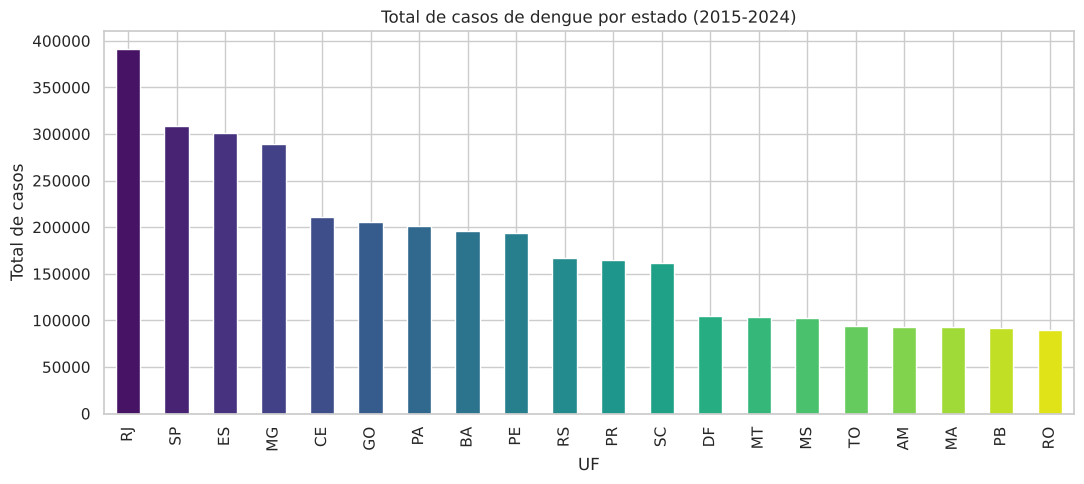

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
casos_por_uf.plot(kind="bar", ax=ax, color=sns.color_palette("viridis", len(casos_por_uf)))
ax.set_title("Total de casos de dengue por estado (2015-2024)")
ax.set_xlabel("UF")
ax.set_ylabel("Total de casos")
plt.tight_layout()
plt.savefig("../imagens/casos_por_uf.png", dpi=130)
plt.show()


### 7.3 Sazonalidade — heatmap mensal (mês x ano)

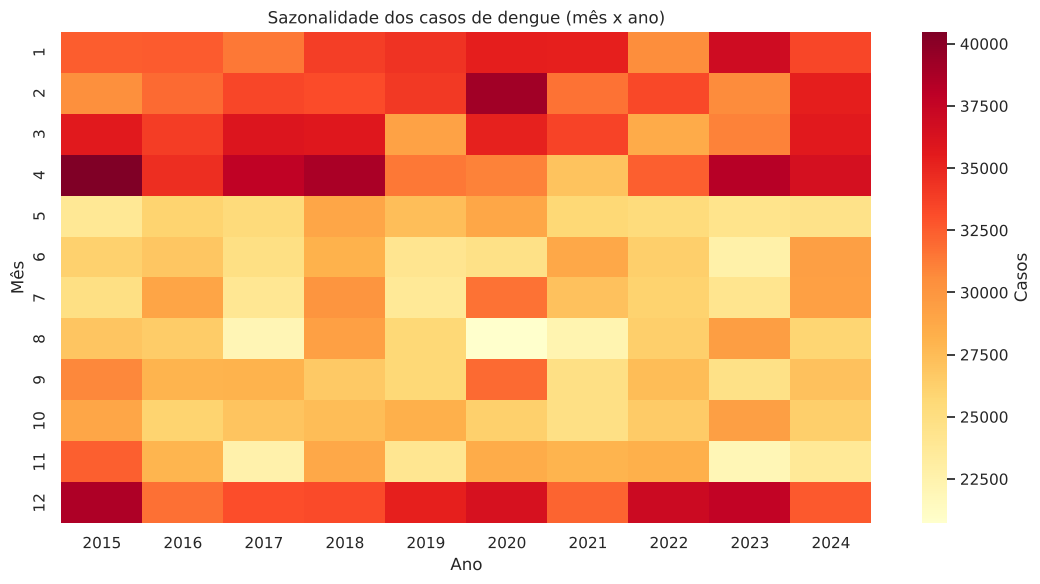

In [9]:
pivot_mes_ano = df.pivot_table(index="mes", columns="ano", values="casos_dengue", aggfunc="sum")

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(pivot_mes_ano, cmap="YlOrRd", annot=False, ax=ax, cbar_kws={"label": "Casos"})
ax.set_title("Sazonalidade dos casos de dengue (mês x ano)")
ax.set_xlabel("Ano")
ax.set_ylabel("Mês")
plt.tight_layout()
plt.savefig("../imagens/heatmap_sazonalidade.png", dpi=130)
plt.show()


### 7.4 Relação entre chuva e casos de dengue (dispersão)

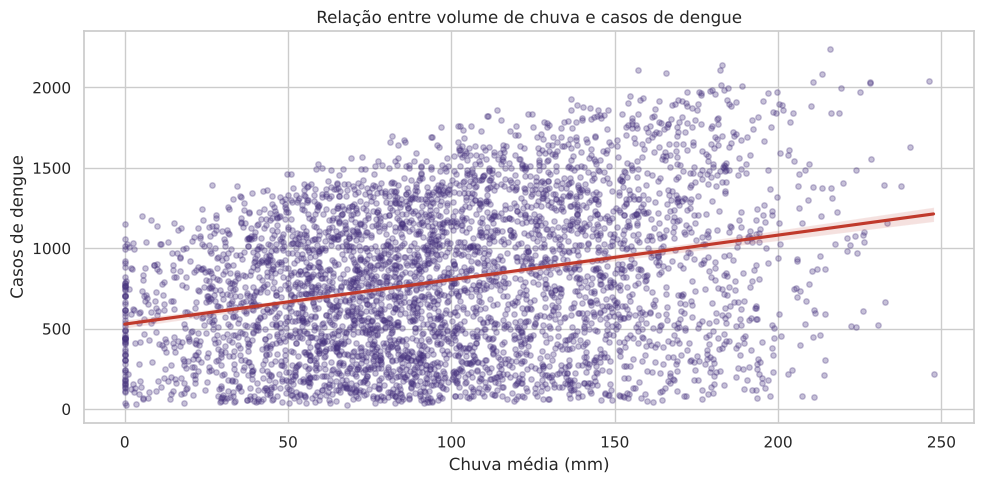

Correlação (Pearson) entre chuva e casos: 0.292


In [10]:
fig, ax = plt.subplots()
sns.regplot(data=df, x="chuva_mm", y="casos_dengue", scatter_kws={"alpha": 0.3, "s": 15}, line_kws={"color": "#c0392b"}, ax=ax)
ax.set_title("Relação entre volume de chuva e casos de dengue")
ax.set_xlabel("Chuva média (mm)")
ax.set_ylabel("Casos de dengue")
plt.tight_layout()
plt.savefig("../imagens/dispersao_chuva_casos.png", dpi=130)
plt.show()

correlacao = df["chuva_mm"].corr(df["casos_dengue"])
print(f"Correlação (Pearson) entre chuva e casos: {correlacao:.3f}")


### 7.5 Ranking de municípios por incidência média

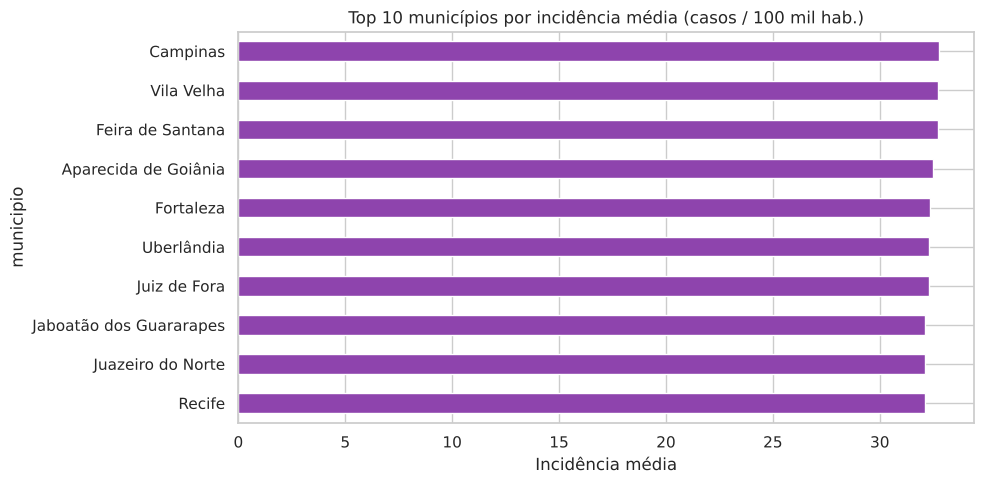

In [11]:
top10_municipios = incidencia_por_municipio.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top10_municipios.sort_values().plot(kind="barh", ax=ax, color="#8e44ad")
ax.set_title("Top 10 municípios por incidência média (casos / 100 mil hab.)")
ax.set_xlabel("Incidência média")
plt.tight_layout()
plt.savefig("../imagens/top10_municipios.png", dpi=130)
plt.show()


## 8. Interpretação dos resultados

In [12]:
casos_2015 = casos_por_ano.loc[2015]
casos_2024 = casos_por_ano.loc[2024]
variacao_pct = (casos_2024 - casos_2015) / casos_2015 * 100

casos_por_mes_medio = df.groupby("mes")["casos_dengue"].sum().sort_values(ascending=False)
mes_critico = casos_por_mes_medio.index[0]

casos_por_regiao = df.groupby("regiao", observed=True)["casos_dengue"].sum().sort_values(ascending=False)
regiao_mais_afetada = casos_por_regiao.index[0]

print(f"- Variação de casos entre 2015 e 2024: {variacao_pct:+.1f}%")
print(f"- Mês historicamente mais crítico: mês {mes_critico} (padrão sazonal associado ao período chuvoso/quente)")
print(f"- Região mais afetada em volume total de casos: {regiao_mais_afetada}")
print(f"- Correlação entre chuva e casos: {correlacao:.3f} (quanto mais próxima de 1, mais forte a relação positiva)")
print(f"- Estado com maior volume de casos: {estado_mais_afetado}")
print(f"- Município com maior incidência média: {municipio_critico}")


- Variação de casos entre 2015 e 2024: -3.2%
- Mês historicamente mais crítico: mês 4 (padrão sazonal associado ao período chuvoso/quente)
- Região mais afetada em volume total de casos: Sudeste
- Correlação entre chuva e casos: 0.292 (quanto mais próxima de 1, mais forte a relação positiva)
- Estado com maior volume de casos: RJ
- Município com maior incidência média: Campinas


A série histórica mostra a evolução dos casos ano a ano, permitindo observar se a
tendência nacional é de crescimento, estabilidade ou queda ao longo da década simulada. O
heatmap mensal evidencia o padrão sazonal: os meses mais críticos tendem a se concentrar no
período mais chuvoso e quente do ano, coerente com o ciclo de proliferação do *Aedes
aegypti*. A dispersão entre chuva e casos confirma (com a força indicada pela correlação
calculada acima) que o volume de precipitação está associado ao aumento de casos, ainda que
outros fatores — como temperatura, saneamento e densidade populacional — também
contribuam. Por fim, o ranking por incidência (casos a cada 100 mil habitantes) evita o viés
de tamanho populacional e aponta os municípios que, proporcionalmente, mais exigem atenção
da vigilância epidemiológica, independentemente de serem grandes centros urbanos ou não.


## 9. Conclusão

O projeto permitiu construir um pipeline completo de análise de dados — da leitura e
limpeza à engenharia de atributos, cálculo de KPIs e visualizações — sobre a evolução dos
casos de dengue no Brasil entre 2015 e 2024. Os resultados reforçam a importância do
monitoramento sazonal (concentração de casos em períodos quentes e chuvosos) e da
priorização regional de políticas públicas, já que a distribuição de casos e de incidência
não é uniforme entre estados e municípios.

Esses achados alimentam diretamente o dashboard interativo (`app.py`, Streamlit), onde os
mesmos filtros, KPIs e visualizações podem ser explorados dinamicamente por ano, mês,
região, estado, município e nível de alerta — permitindo que gestores de saúde pública
identifiquem rapidamente períodos e locais críticos para ação preventiva.
